<a href="https://colab.research.google.com/github/deepakvarghesevm/Case_Study_Starter_Notebook_Airbnb_NYC_Preprocessing_deepak_varghese.ipynb/blob/main/Case_Study_Starter_Notebook_Airbnb_NYC_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study Assessment — NYC Airbnb Data Preprocessing
### Student Name:
### Date:

This notebook is your submission template. Fill in each section — do not delete the headers. Use markdown cells for your written justifications, right next to the code that supports them.

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

---
## Part 1 — Data Understanding & Quality Audit

In [ ]:
# TODO: shape, dtypes, missing value summary
print(df.shape)
print(df.dtypes)
df.isnull().sum()

In [ ]:
# TODO: check for values that are technically present but don't make real-world sense
# print(df.describe())
print("price == 0 count:", (df['price']==0).sum())# in the real world, price should not be 0 if it given reviews and availability. So, we can consider these as unrealistic value for this case.
print("maximum minimum nights:", df['minimum_nights'].max())# in the real world, minimum_nights should not be excessively high. So, we can consider these as outliers.
df.describe()


In [ ]:
# TODO: duplicate check

print( df.duplicated().sum())#no duplicate rows found in the dataset


**Written notes — what did you find, and what looks suspicious?**

_Your answer here._

---
## Part 2 — Missing Value Diagnosis & Treatment

In [ ]:
# TODO: investigate missingness pattern(s) across columns

print(df.isnull().sum())

print(df[['reviews_per_month', 'last_review']].isnull().sum())
#last_review and reviews_per_month missingness is strongly associated with listings having 0 reviews.
#Therefore, these missing values are meaningful rather than random.
#then it is MAR

#in the case of name,and host_name, the missingness is not associated with any other variable like id ,host_id.
#  Therefore, it is MCAR. We can drop these rows as they are very few in number and will not affect the analysis.

**Written justification — MCAR / MAR / MNAR classification per column, and your reasoning:**

_Your answer here._

In [ ]:
# TODO: apply your chosen treatment(s)
# Replace missing reviews_per_month with 0 for listings with no reviews
df.loc[df['number_of_reviews'] == 0, 'reviews_per_month'] = 0

# Drop rows where name or host_name is missing
df = df.dropna(subset=['name', 'host_name'])
missing_percentage = df['last_review'].isnull().mean() * 100
print( missing_percentage)
df['last_review'] = df['last_review'].fillna('No Review')
print(df.isnull().sum())
#Using df.dropna() would remove every row containing at least one missing value.
# This could discard a large amount of useful data,
#  especially because last_review and reviews_per_month have many missing values.
# It could also reduce the dataset unnecessarily and potentially introduce bias if the missingness is not random.
df

**Written justification — why this treatment for each column, and what you'd risk with `dropna()` instead:**

_Your answer here._

---
## Part 3 — Outlier Detection & Treatment

In [ ]:
# TODO: detect outliers in at least two numeric columns
df.info()

In [ ]:
%pip install matplotlib

In [ ]:
%pip install seaborn

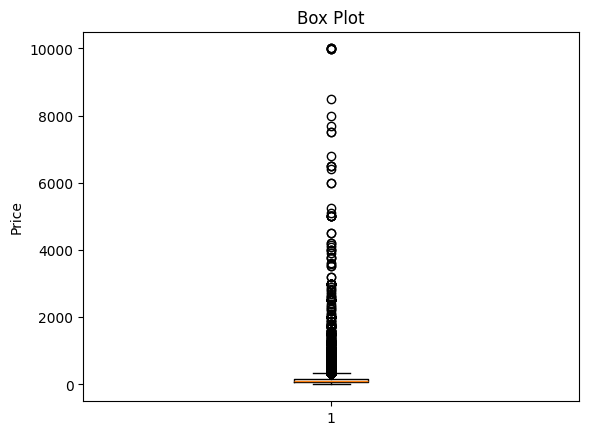

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.boxplot(df['price'])
plt.ylabel('Price')
plt.title('Box Plot')
plt.show()

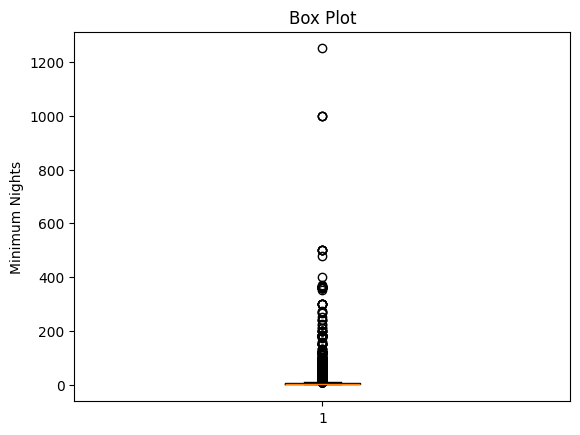

In [ ]:
plt.boxplot(df['minimum_nights'])
plt.ylabel('Minimum Nights')
plt.title('Box Plot')
plt.show()

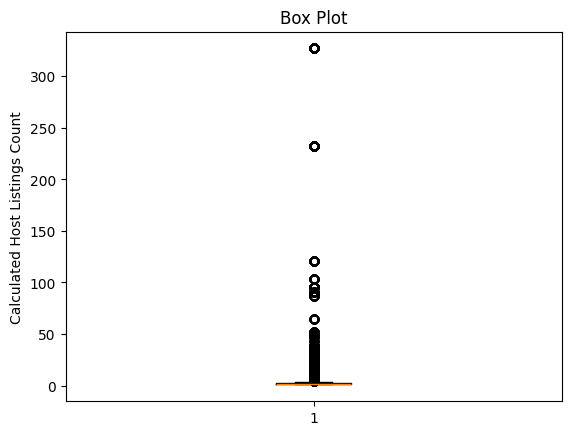

In [ ]:
plt.boxplot(df['calculated_host_listings_count'])
plt.ylabel('Calculated Host Listings Count')
plt.title('Box Plot')
plt.show()

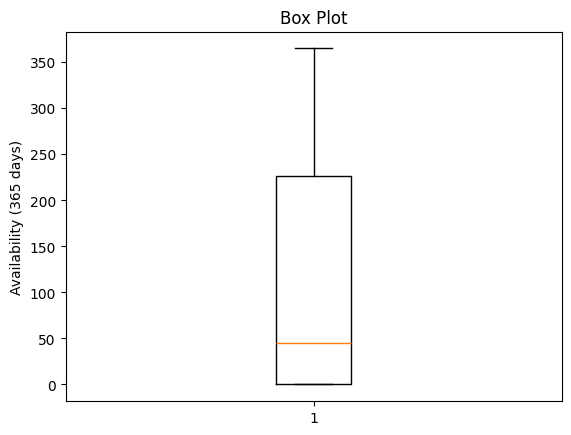

In [ ]:
plt.boxplot(df['availability_365'])
plt.ylabel('Availability (365 days)')
plt.title('Box Plot')
plt.show()

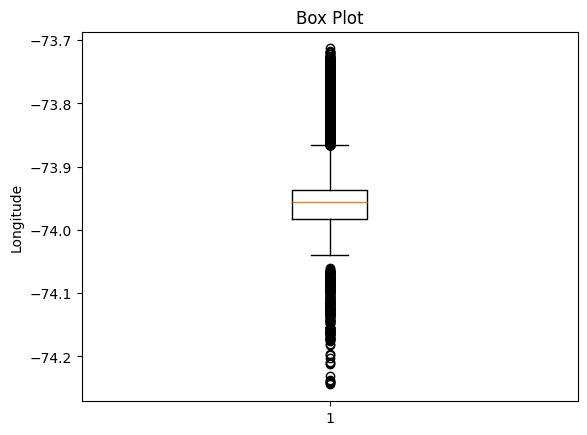

In [ ]:
plt.boxplot(df['longitude'])
plt.ylabel('Longitude')
plt.title('Box Plot')
plt.show()

In [ ]:
print(df['minimum_nights'].sort_values(ascending=False).head(10))
#"The box plot identified extreme values in minimum_nights.
#  Further investigation showed values as high as 1,250 nights, which represents a minimum stay of more than three years.
#  This is unrealistic for the rental listings being analyzed, so these values are treated as invalid/extreme values."

5767     1250
38664     999
13404     999
26341     999
7355      500
11193     500
47620     500
14285     500
8014      500
10829     480
Name: minimum_nights, dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48858 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48858 non-null  int64  
 1   name                            48858 non-null  object 
 2   host_id                         48858 non-null  int64  
 3   host_name                       48858 non-null  object 
 4   neighbourhood_group             48858 non-null  object 
 5   neighbourhood                   48858 non-null  object 
 6   latitude                        48858 non-null  float64
 7   longitude                       48858 non-null  float64
 8   room_type                       48858 non-null  object 
 9   price                           48858 non-null  int64  
 10  minimum_nights                  48858 non-null  int64  
 11  number_of_reviews               48858 non-null  int64  
 12  last_review                     48858

In [ ]:
print(df['price'].sort_values(ascending=False).head(20))


9151     10000
29238    10000
17692    10000
40433     9999
12342     9999
6530      9999
30268     8500
4377      8000
29662     7703
42523     7500
45666     7500
44034     6800
37194     6500
48043     6500
3774      6500
29664     6419
15560     6000
3537      6000
3720      5250
43009     5100
Name: price, dtype: int64


In [ ]:
high_price_listings = df.loc[
    df["price"] > 5000,
    ["price", "room_type", "neighbourhood", "minimum_nights"]
]

print(high_price_listings.head(10))

       price        room_type      neighbourhood  minimum_nights
3537    6000  Entire home/apt    Upper West Side              14
3720    5250  Entire home/apt       Little Italy               1
3774    6500  Entire home/apt       Clinton Hill               1
4377    8000  Entire home/apt       Clinton Hill               1
6530    9999  Entire home/apt        East Harlem               5
9151   10000     Private room            Astoria             100
12342   9999     Private room    Lower East Side              99
15560   6000  Entire home/apt  Greenwich Village               1
17692  10000  Entire home/apt         Greenpoint               5
29238  10000  Entire home/apt    Upper West Side              30


In [ ]:
high_price = df[df['price'] > 5000]

print(high_price[['price', 'room_type', 'neighbourhood']])


df.groupby(['neighbourhood', 'room_type'])['price'].describe()

#The box plot identified many potential outliers in price. However, price varies considerably depending on room type and neighborhood.
#  Therefore, extreme prices should not be removed solely based on the box plot.
#  I investigated the high-price listings using room_type and neighbourhood to determine whether the values could be legitimate.

       price        room_type      neighbourhood
3537    6000  Entire home/apt    Upper West Side
3720    5250  Entire home/apt       Little Italy
3774    6500  Entire home/apt       Clinton Hill
4377    8000  Entire home/apt       Clinton Hill
6530    9999  Entire home/apt        East Harlem
9151   10000     Private room            Astoria
12342   9999     Private room    Lower East Side
15560   6000  Entire home/apt  Greenwich Village
17692  10000  Entire home/apt         Greenpoint
29238  10000  Entire home/apt    Upper West Side
29662   7703  Entire home/apt    Upper East Side
29664   6419  Entire home/apt    Upper East Side
30268   8500  Entire home/apt            Tribeca
37194   6500     Private room    Upper West Side
40433   9999  Entire home/apt    Lower East Side
42523   7500  Entire home/apt  Battery Park City
43009   5100  Entire home/apt            Midtown
44034   6800  Entire home/apt            Chelsea
45666   7500     Private room      East Flatbush
48043   6500  Entire

count        mean         std    min     25%  \
neighbourhood room_type                                                       
Allerton      Entire home/apt   16.0  123.062500   99.812136   49.0   73.75   
              Private room      26.0   65.769231   38.382608   33.0   38.25   
Arden Heights Entire home/apt    3.0   76.000000    6.557439   70.0   72.50   
              Private room       1.0   41.000000         NaN   41.0   41.00   
Arrochar      Entire home/apt   10.0  189.700000  164.161201   60.0  105.50   
...                              ...         ...         ...    ...     ...   
Woodlawn      Shared room        1.0   70.000000         NaN   70.0   70.00   
Woodrow       Entire home/apt    1.0  700.000000         NaN  700.0  700.00   
Woodside      Entire home/apt   63.0  148.714286   82.173779   50.0   99.50   
              Private room     171.0   61.777778   48.714387   28.0   40.00   
              Shared room        1.0   65.000000         NaN   65.0   65.00   

                                 50%     75%    max  
neighbourhood room_type                              
Allerton      Entire home/apt   95.0  128.75  450.0  
              Private room      49.0   77.50  142.0  
Arden Heights Entire home/apt   75.0   79.00   83.0  
              Private room      41.0   41.00   41.0  
Arrochar      Entire home/apt  137.5  198.00  625.0  
...                              ...     ...    ...  
Woodlawn      Shared room       70.0   70.00   70.0  
Woodrow       Entire home/apt  700.0  700.00  700.0  
Woodside      Entire home/apt  125.0  169.00  500.0  
              Private room      50.0   70.00  475.0  
              Shared room       65.0   65.00   65.0  

[540 rows x 8 columns]

In [ ]:
Q1 = df.groupby('room_type')['price'].transform('quantile', 0.25)
Q3 = df.groupby('room_type')['price'].transform('quantile', 0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

price_outliers = df[(df['price'] > upper_limit) | (df['price'] < lower_limit)]

print("Number of price outliers:", len(price_outliers))

print(price_outliers[
    ['price', 'room_type', 'neighbourhood']
].head(20))

Number of price outliers: 3243
     price        room_type     neighbourhood
76     200     Private room   Upper East Side
85     800  Entire home/apt  Brooklyn Heights
103    500  Entire home/apt      West Village
121    400  Entire home/apt       South Slope
158    475  Entire home/apt       Boerum Hill
163    250     Private room             DUMBO
204    200     Private room            Harlem
233    500  Entire home/apt              SoHo
237    175     Private room            Harlem
242    500  Entire home/apt           Chelsea
299    575  Entire home/apt      Little Italy
304    500  Entire home/apt      East Village
321    179     Private room        Greenpoint
327    349     Private room        Greenpoint
328    349     Private room        Greenpoint
330    249     Private room        Greenpoint
339    179     Private room        Greenpoint
345    650  Entire home/apt      Clinton Hill
354    165     Private room      Clinton Hill
365    599     Private room        Greenpoint


**Written justification — for each outlier group, is it an error or a genuine listing? What evidence supports your call?**

_Your answer here.


Price: The 11 rows with price = 0 are errors — no real listing rents for free — and were dropped. Prices above $5,000, even up to $10,000, are genuine — grouping by neighbourhood and room_type showed entire-home listings in areas like Tribeca and Upper West Side legitimately reach that range, so they were kept untouched since price is the model's target variable.

Minimum nights: Values like 1250, 999, and 500 nights are errors — they exceed availability_365, meaning the listing claims a minimum stay longer than it's ever available, which is logically impossible. These were capped at 365 rather than dropped, since the listing itself is still valid — only the number was wrong.

In [ ]:
Q1 = df['minimum_nights'].quantile(0.25)
Q3 = df['minimum_nights'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR


outliers = df[(df['minimum_nights'] > upper_limit) | (df['minimum_nights'] < lower_limit)]

print("Number of outliers:", len(outliers))
print(outliers[['minimum_nights', 'price', 'room_type', 'neighbourhood']].head(20))

Number of outliers: 6605
     minimum_nights  price        room_type              neighbourhood
6                45     60     Private room         Bedford-Stuyvesant
14               90    120  Entire home/apt               West Village
29               14    180  Entire home/apt               East Village
36               60     35     Private room         Bedford-Stuyvesant
45               29    150  Entire home/apt  Prospect-Lefferts Gardens
55               30    150  Entire home/apt               Williamsburg
59               30    180  Entire home/apt                       SoHo
61              180    375  Entire home/apt                    Chelsea
63               30    200  Entire home/apt           Prospect Heights
65               30     52     Private room             Hell's Kitchen
77               30     70     Private room                   Woodside
81               31    110  Entire home/apt                     Harlem
84               30     94     Private room         

In [ ]:
# TODO: apply treatment consistent with your judgment above
# Remove unrealistic minimum-stay requirements
df = df[df['price'] > 0]
df.loc[df['minimum_nights'] > 365, 'minimum_nights'] = 365
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48847 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48847 non-null  int64  
 1   name                            48847 non-null  object 
 2   host_id                         48847 non-null  int64  
 3   host_name                       48847 non-null  object 
 4   neighbourhood_group             48847 non-null  object 
 5   neighbourhood                   48847 non-null  object 
 6   latitude                        48847 non-null  float64
 7   longitude                       48847 non-null  float64
 8   room_type                       48847 non-null  object 
 9   price                           48847 non-null  int64  
 10  minimum_nights                  48847 non-null  int64  
 11  number_of_reviews               48847 non-null  int64  
 12  last_review                     48847

---
## Part 4 — Feature Engineering & Encoding

In [ ]:
# TODO: encode categorical columns appropriately
for col in ['neighbourhood_group', 'neighbourhood', 'room_type']:
    print(col,df[col].nunique())

neighbourhood_group 5
neighbourhood 221
room_type 3


In [ ]:
df=pd.get_dummies(df,columns=['neighbourhood_group'],drop_first=True,dtype=int)
df=pd.get_dummies(df,columns=['room_type'],drop_first=True,dtype=int)

In [ ]:
neigh_freq = df['neighbourhood'].value_counts(normalize=True)
df['neighbourhood_freq'] = df['neighbourhood'].map(neigh_freq)
df = df.drop(columns=['neighbourhood'])
df = df.drop(columns=['name', 'host_name'])
df = df.drop(columns=['last_review'])

In [ ]:
df

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room,neighbourhood_freq
0,2539,2787,40.64749,-73.97237,149,1,9,0.21,6,365,1,0,0,0,1,0,0.003583
1,2595,2845,40.75362,-73.98377,225,1,45,0.38,2,355,0,1,0,0,0,0,0.031629
2,3647,4632,40.80902,-73.94190,150,3,0,0.00,1,365,0,1,0,0,1,0,0.054353
3,3831,4869,40.68514,-73.95976,89,1,270,4.64,1,194,1,0,0,0,0,0,0.011710
4,5022,7192,40.79851,-73.94399,80,10,9,0.10,1,0,0,1,0,0,0,0,0.022847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,8232441,40.67853,-73.94995,70,2,0,0.00,2,9,1,0,0,0,1,0,0.075931
48891,36485057,6570630,40.70184,-73.93317,40,4,0,0.00,2,36,1,0,0,0,1,0,0.050341
48892,36485431,23492952,40.81475,-73.94867,115,10,0,0.00,1,27,0,1,0,0,0,0,0.054353
48893,36485609,30985759,40.75751,-73.99112,55,1,0,0.00,6,2,0,1,0,0,0,1,0.040002


In [ ]:
# TODO: engineer at least two new features
df['is_multi_listing_host'] = (df['calculated_host_listings_count'] > 1).astype(int)
df['availability_ratio'] = df['availability_365'] / 365
df

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room,neighbourhood_freq,is_multi_listing_host,availability_ratio
0,2539,2787,40.64749,-73.97237,149,1,9,0.21,6,365,1,0,0,0,1,0,0.003583,1,1.000000
1,2595,2845,40.75362,-73.98377,225,1,45,0.38,2,355,0,1,0,0,0,0,0.031629,1,0.972603
2,3647,4632,40.80902,-73.94190,150,3,0,0.00,1,365,0,1,0,0,1,0,0.054353,0,1.000000
3,3831,4869,40.68514,-73.95976,89,1,270,4.64,1,194,1,0,0,0,0,0,0.011710,0,0.531507
4,5022,7192,40.79851,-73.94399,80,10,9,0.10,1,0,0,1,0,0,0,0,0.022847,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,8232441,40.67853,-73.94995,70,2,0,0.00,2,9,1,0,0,0,1,0,0.075931,1,0.024658
48891,36485057,6570630,40.70184,-73.93317,40,4,0,0.00,2,36,1,0,0,0,1,0,0.050341,1,0.098630
48892,36485431,23492952,40.81475,-73.94867,115,10,0,0.00,1,27,0,1,0,0,0,0,0.054353,0,0.073973
48893,36485609,30985759,40.75751,-73.99112,55,1,0,0.00,6,2,0,1,0,0,0,1,0.040002,1,0.005479


**Written justification — why these features, and which column(s) should NOT be used to predict price, and why:**


New features: is_multi_listing_host distinguishes commercial hosts (multiple properties, standardized pricing) from individual homeowners, and availability_ratio captures whether a listing is run as a full-time rental business or an occasional spare-room — both are real pricing-strategy signals a guest or host would recognize, not just numeric noise
_Your answer here._

 and which column(s) should NOT be used to predict price, and why is last_reieww


---
## Part 5 — Build a Reusable Preprocessing Pipeline

In [ ]:
%pip install scikit-learn

In [ ]:
# TODO: train/test split (before fitting anything)
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (39077, 18)
Test shape: (9770, 18)


In [ ]:
# TODO: build Pipeline combining your cleaning, imputation, encoding, scaling steps
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [ ]:

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_columns)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train.shape, X_test.shape)
print(X_train_processed.shape, X_test_processed.shape)


(39077, 16) (9770, 16)
(39077, 16) (9770, 16)


---
## Part 6 — Written Reflection
1. Largest-effect decision:
Grouping price outliers by room_type instead of using one global cutoff — a flat threshold would've wrongly flagged legitimate high-price Entire home/apt listings as errors, shrinking the price range the model could learn from.

2. What changes for live data:
The manual cleaning steps (dropping bad rows, capping values, encoding) would need to run inside an automated pipeline instead of one-off cells, since new listings can't be manually checked each time, and the pipeline would need periodic re-fitting as pricing patterns shift.

3. Answer to stakeholder:
Deleting every unusual row would remove real listings — like luxury properties or new hosts with no reviews yet — and bias the model toward only "average" cases. Most of what looked unusual turned out to be genuine signal once checked, not errors.